In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ファイルパス（先ほどリネームして保存した名前）
file_path = "../data/raw/cicids/02-14-2018.csv"

# 読み込み（400MB弱あるので、数秒かかります）
# low_memory=False を指定して型推論の警告を回避します
df = pd.read_csv(file_path, low_memory=False)

# カラム名にスペースが含まれている場合があるため、トリミングしておく
df.columns = df.columns.str.strip()

print(f"データの総行数: {len(df):,}")
print("-" * 30)
# 最初の5行を表示
display(df.head())

データの総行数: 1,048,575
------------------------------


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


ラベルの内訳:
Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64


/tmp/ipykernel_27531/3289155055.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


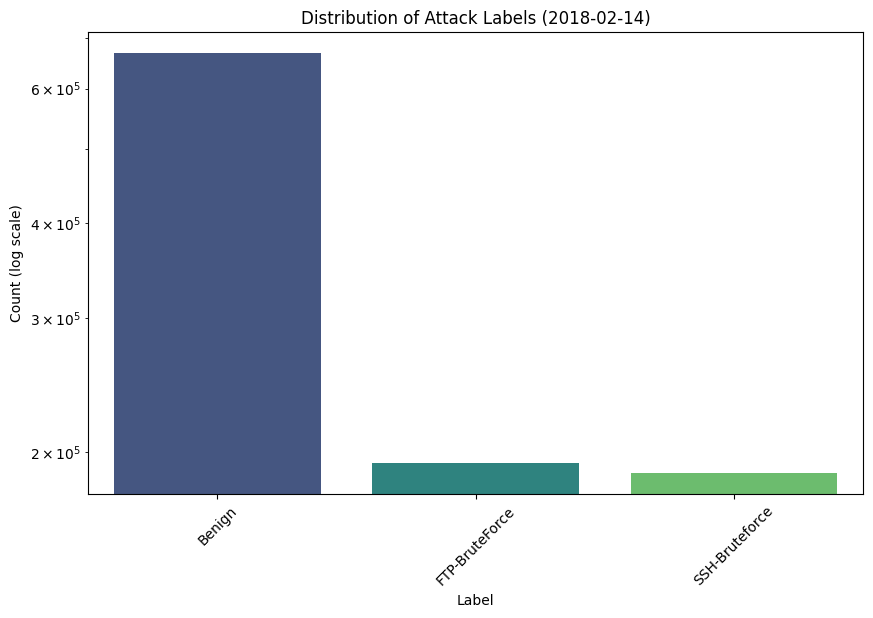

In [6]:
# ラベルごとの件数をカウント
label_counts = df['Label'].value_counts()
print("ラベルの内訳:")
print(label_counts)

# 棒グラフで可視化
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Attack Labels (2018-02-14)')
plt.xlabel('Label')
plt.ylabel('Count (log scale)')
plt.yscale('log') # 件数差が激しいため対数スケールにすると見やすいです
plt.xticks(rotation=45)
plt.show()